<a href="https://colab.research.google.com/github/carlosjimenezortega/PROCESOS-ESTOCASTICOS/blob/main/Simulaci%C3%B3nGPs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SIMULACIÓN Y VISUALIZACIÓN DE GPs**

In [ ]:
# Importamos librerías necesarias

import numpy as np
import matplotlib.pyplot as plt
import math

**1. Muestras de una normal multivariante:**


Empezaremos simulando trayectorias de una normal multivariante ya que nos ayudará para luego las del GP.

En la siguiente celda se obtienen 50 muestras de una normal 3-dimensional  (X1,X2,X3)  que sigue una distribución normal  N(0,I3×3)

Para ello, usaré la función np.random.multivariate_normal.

Además, visualizamos el resultado obtenido, así como su shape.

In [ ]:

vector_medias = np.zeros(3)
matriz_covarianzas = np.identity(3)
num_samples = 50
samples = np.random.multivariate_normal(mean = vector_medias,cov = matriz_covarianzas,size = num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-0.66478299 -0.25514385  0.42588205]
 [ 0.38494309  0.73198174  0.96039545]
 [-0.34889245 -0.61497319 -0.38961776]
 [-0.67186056 -1.20692883  0.78750101]
 [-0.983278   -0.60323255  0.92163507]
 [-1.13146036  0.70648763 -1.44258074]
 [ 1.95440692  0.70628204 -0.31686498]
 [-1.29413592 -0.78646409  1.3574395 ]
 [ 0.65866171 -0.16042811  1.49214605]
 [-0.64111416 -0.03328462  0.45819431]
 [ 0.06546733  2.28937175 -2.19056441]
 [-1.26839929 -0.15446746 -0.07153895]
 [-0.4778206  -1.38874636  0.78215136]
 [ 0.18584113 -2.21255547  0.4415892 ]
 [ 0.08310145 -0.65715911 -1.3641321 ]
 [ 0.17701506  1.4779001  -1.55921429]
 [-0.16620793 -0.6624579  -1.19300702]
 [-0.82790675  0.11620261 -1.56751126]
 [ 0.44613025  0.05367617 -0.50943565]
 [ 0.95612562 -0.60309993 -0.01888591]
 [-0.27846987 -0.77907666  0.49185552]
 [-1.49120525  1.90144662 -0.08027896]
 [-2.18291351 -1.39599941  0.42041959]
 [ 0.55057307 -1.04971745 -0.48129996]
 [-1.06113078  2.15768384  0.36618543

Ahora lo mismo pero para una con la matriz de covarianzas dada:
$$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$


In [ ]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1,10,100]) # Para crear la diagonal np.diag
num_samples = 50
samples = np.random.multivariate_normal(mean = vector_medias,cov = matriz_covarianzas,size = num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 3.45119488e-01 -4.42321174e-01  4.53518600e+00]
 [ 5.56306565e-01 -3.92415012e+00  7.17962588e+00]
 [-5.65886990e-01 -1.31026565e-01 -4.09915413e+00]
 [-1.25098225e-01 -3.93478899e+00  7.11113578e+00]
 [ 1.28690460e+00  5.00113130e+00  2.04296741e+01]
 [-1.41172658e+00  3.02814059e+00  1.73058631e+01]
 [-1.35338712e+00  1.74431534e+00  3.07391309e+00]
 [ 1.95772533e+00  4.74127198e+00  1.03141605e+00]
 [ 1.39424772e+00 -4.11223955e+00 -4.53750641e+00]
 [ 1.38626183e+00 -4.25494454e+00 -2.15074950e+00]
 [ 1.31143608e+00  1.64439469e+00  9.56850505e+00]
 [-2.71474181e+00 -2.24891417e+00 -1.56007120e+00]
 [ 1.22597186e+00 -3.27144879e+00 -9.94341472e+00]
 [-7.62172915e-01 -4.17166310e-01  1.53916062e+01]
 [-7.40051348e-03 -1.85311136e+00 -4.11027618e+00]
 [ 1.27040121e+00  2.16079485e+00 -1.07763365e+01]
 [ 7.98767803e-01  7.52010507e-01 -2.36559608e+01]
 [ 1.52321221e+00  1.00140178e+00  4.24926123e+00]
 [ 9.06984953e-01  2.23428766e+00  2.98433061e+01]
 [ 1

**2. Simular el GP con kernel RBF**

Aquí definiremos la función principal simular_GP_RBF que será el esqueleto del proyecto. Más adelante la sustituiremos por simular_GP. Usaremos vector de medias constantemente cero.

In [ ]:
def simular_GP_RBF(t, sigma_sq, lengthscale, num_samples):

  vector_medias = np.zeros_like(t) ## Vector de ceros de tamaño y tipo t

  # Matriz de covarianzas. Usando la vectorización de numpy y broadcasting.
  tf = t.reshape(1, t.shape[0])
  tc = t.reshape(t.shape[0], 1)
  matriz_distancias = tf - tc
  matriz_covs = sigma_sq * np.exp(-0.5 * matriz_distancias**2 / lengthscale**2)

  # Muestras
  samples = np.random.multivariate_normal(mean = vector_medias,cov = matriz_covs,size = num_samples)

  return samples

Ahora vamos a recrear algunas gráficas vistas en teoría.

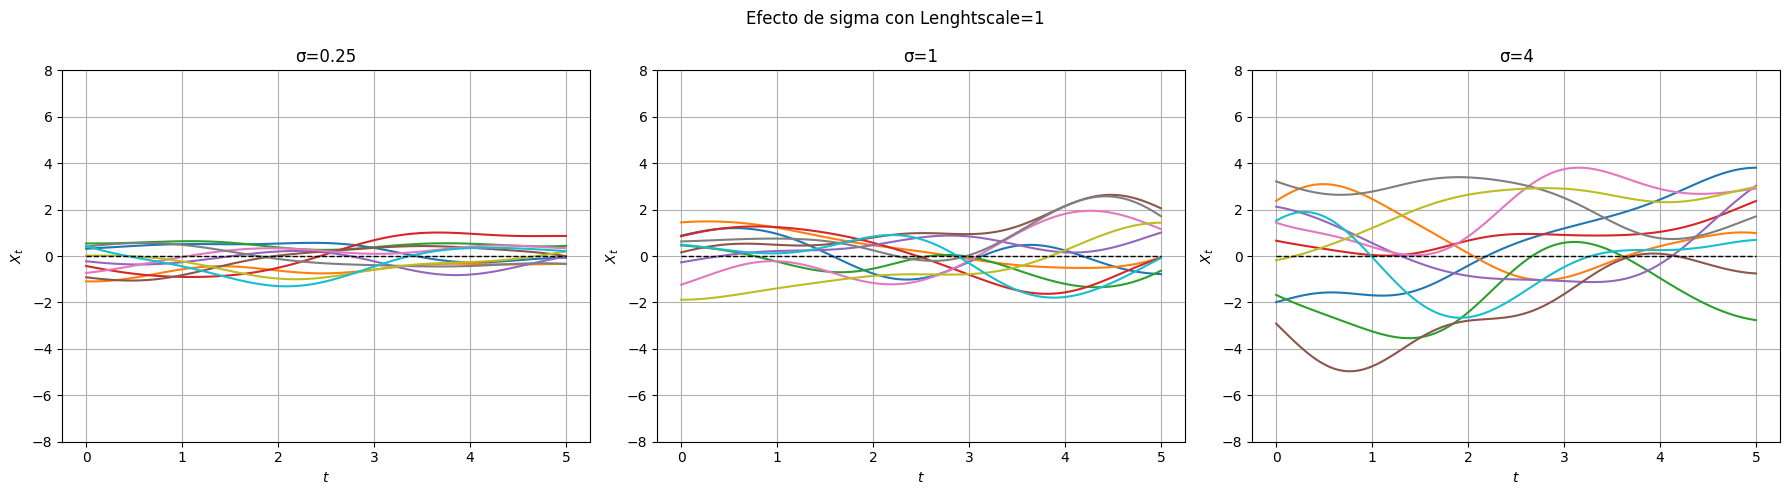

In [ ]:
t = np.linspace(0, 5, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle('Efecto de sigma con Lenghtscale=1')

axes[0].plot(t, simular_GP_RBF (t, 0.25, 1, 10).T)
axes[0].grid()
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_ylim(-8,8)
axes[0].plot(t,np.zeros_like(t),'black',linestyle='--',linewidth=1)
axes[0].set_title('σ=0.25')


axes[1].plot(t, simular_GP_RBF (t, 1 ,1, 10).T)
axes[1].grid()
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_ylim(-8,8)
axes[1].plot(t,np.zeros_like(t),'black',linestyle='--',linewidth=1)
axes[1].set_title('σ=1')

axes[2].plot(t, simular_GP_RBF (t, 4, 1, 10).T)
axes[2].grid()
axes[2].set_xlabel('$t$')
axes[2].set_ylabel('$X_t$')
axes[2].set_ylim(-8,8)
axes[2].plot(t,np.zeros_like(t),'black',linestyle='--',linewidth=1)
axes[2].set_title('σ=4')


plt.tight_layout()
plt.show()

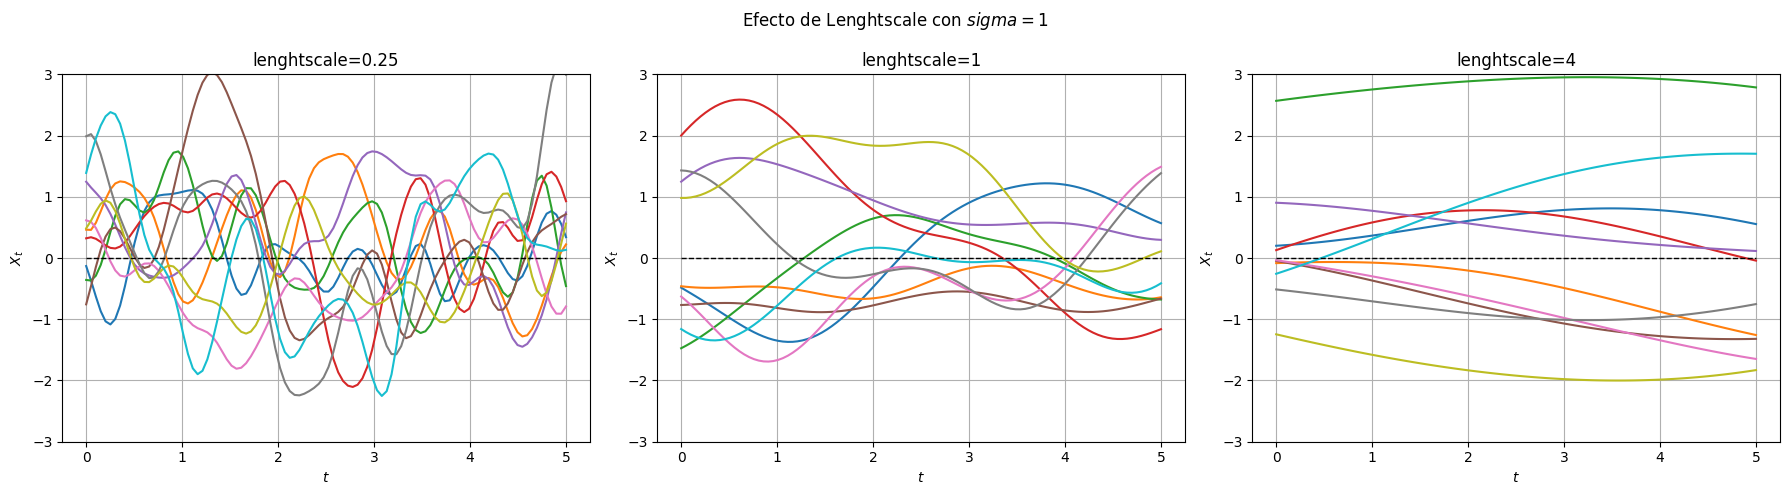

In [ ]:
t = np.linspace(0, 5, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle('Efecto de Lenghtscale con $sigma=1$')

axes[0].plot(t, simular_GP_RBF (t, 1, 0.25, 10).T)
axes[0].grid()
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_ylim(-3,3)
axes[0].plot(t,np.zeros_like(t),'black',linestyle='--',linewidth=1)
axes[0].set_title('lenghtscale=0.25')


axes[1].plot(t, simular_GP_RBF (t, 1 ,1, 10).T)
axes[1].grid()
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_ylim(-3,3)
axes[1].plot(t,np.zeros_like(t),'black',linestyle='--',linewidth=1)
axes[1].set_title('lenghtscale=1')

axes[2].plot(t, simular_GP_RBF (t, 1, 4, 10).T)
axes[2].grid()
axes[2].set_xlabel('$t$')
axes[2].set_ylabel('$X_t$')
axes[2].set_ylim(-3,3)
axes[2].plot(t,np.zeros_like(t),'black',linestyle='--',linewidth=1)
axes[2].set_title('lenghtscale=4')


plt.tight_layout()
plt.show()

**3. Simular un GP con kernel periódico.**

Ahora definiremos la función simular_GP_periodic para simular un GP con kernel periódico.


In [ ]:
def simular_GP_periodic(t, sigma_sq, lengthscale, periodo, num_samples):

  vector_medias = np.zeros_like(t) ## Vector de ceros de tamaño y tipo t

  # Matriz de covarianzas.
  tf = t.reshape(1, t.shape[0])
  tc = t.reshape(t.shape[0], 1)
  matriz_distancias = tf - tc
  matriz_covs = matriz_covs = sigma_sq * np.exp(-2 * np.sin(np.pi * np.abs(matriz_distancias) / periodo)**2 / lengthscale**2)

  # Muestras
  samples = np.random.multivariate_normal(mean = vector_medias,cov = matriz_covs,size = num_samples)

  return samples

De nuevo, recreemos gráficas vistas en teoría.

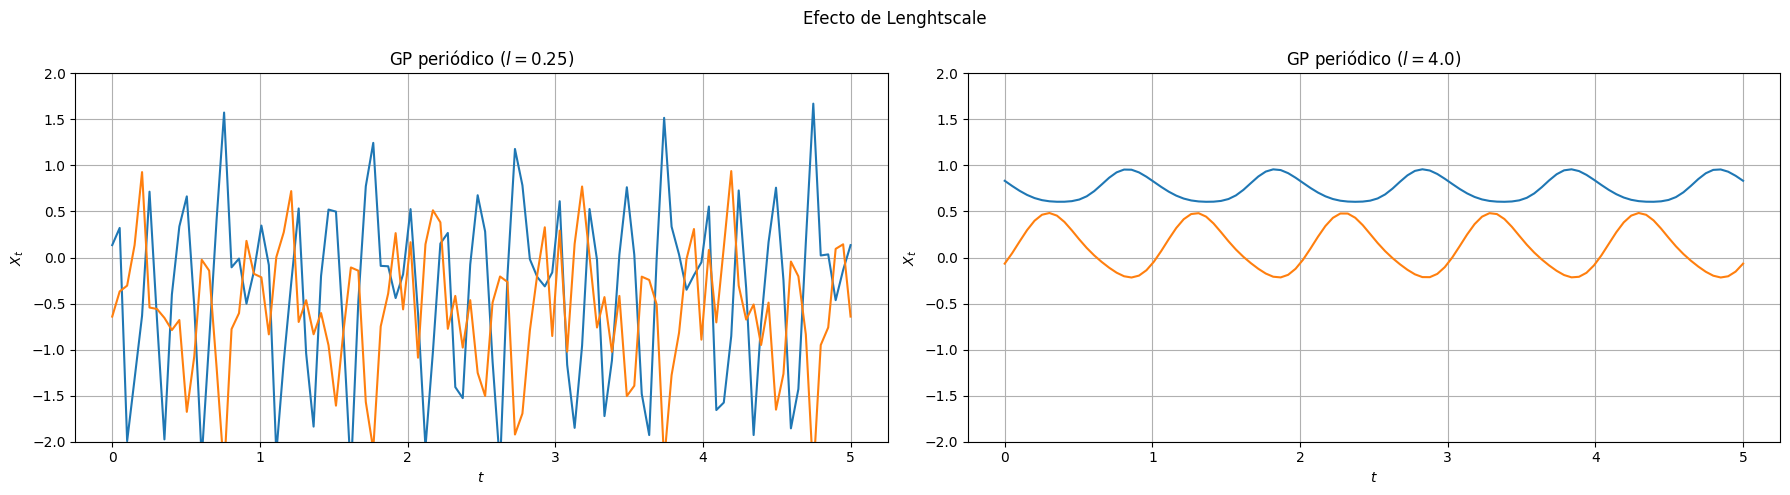

In [ ]:
t = np.linspace(0, 5, 100)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plt.suptitle('Efecto de Lenghtscale')

axes[0].plot(t, simular_GP_periodic (t, 1, 0.25 ,1, 2).T)
axes[0].grid()
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_ylim(-2,2)
axes[0].set_title('GP periódico ($l = 0.25$)')


axes[1].plot(t, simular_GP_periodic (t, 1 ,4.0 , 1, 2).T)
axes[1].grid()
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_ylim(-2,2)
axes[1].set_title('GP periódico ($l = 4.0$)')

plt.tight_layout()
plt.show()

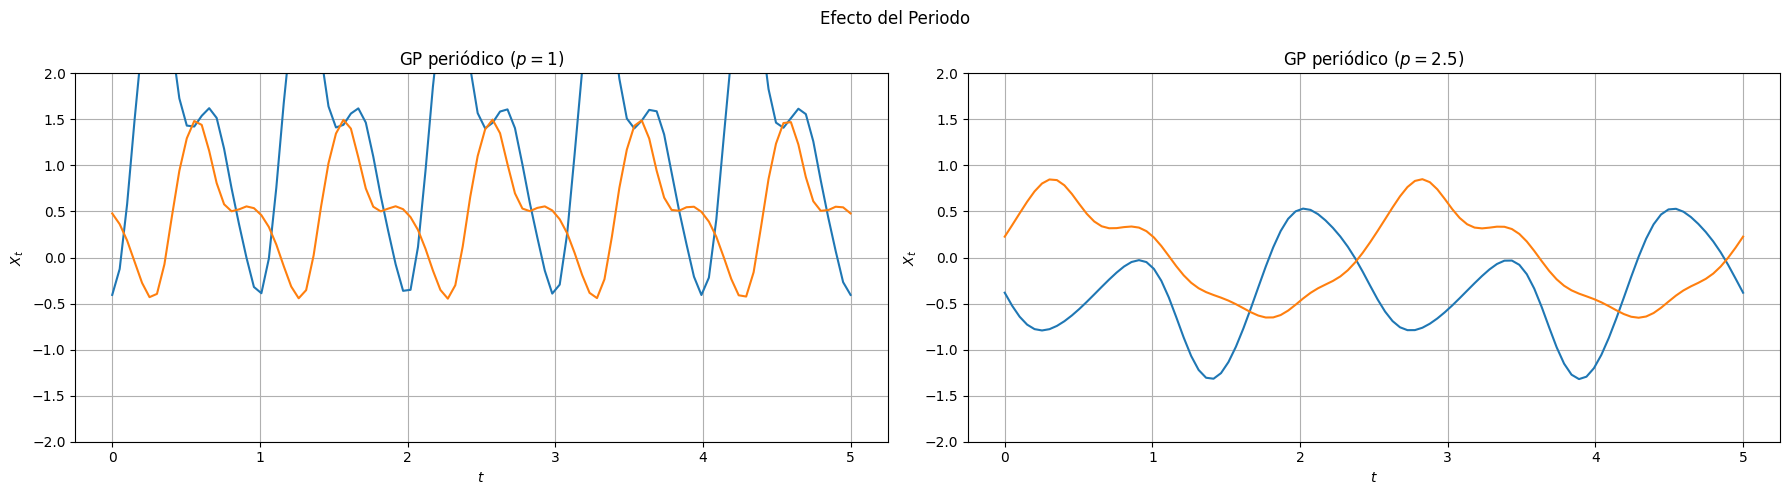

In [ ]:
t = np.linspace(0, 5, 100)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plt.suptitle('Efecto del Periodo')

axes[0].plot(t, simular_GP_periodic (t, 1, 1 ,1, 2).T)
axes[0].grid()
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_ylim(-2,2)
axes[0].set_title('GP periódico ($p = 1$)')


axes[1].plot(t, simular_GP_periodic (t, 1 ,1 , 2.5, 2).T)
axes[1].grid()
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_ylim(-2,2)
axes[1].set_title('GP periódico ($p = 2.5$)')

plt.tight_layout()
plt.show()

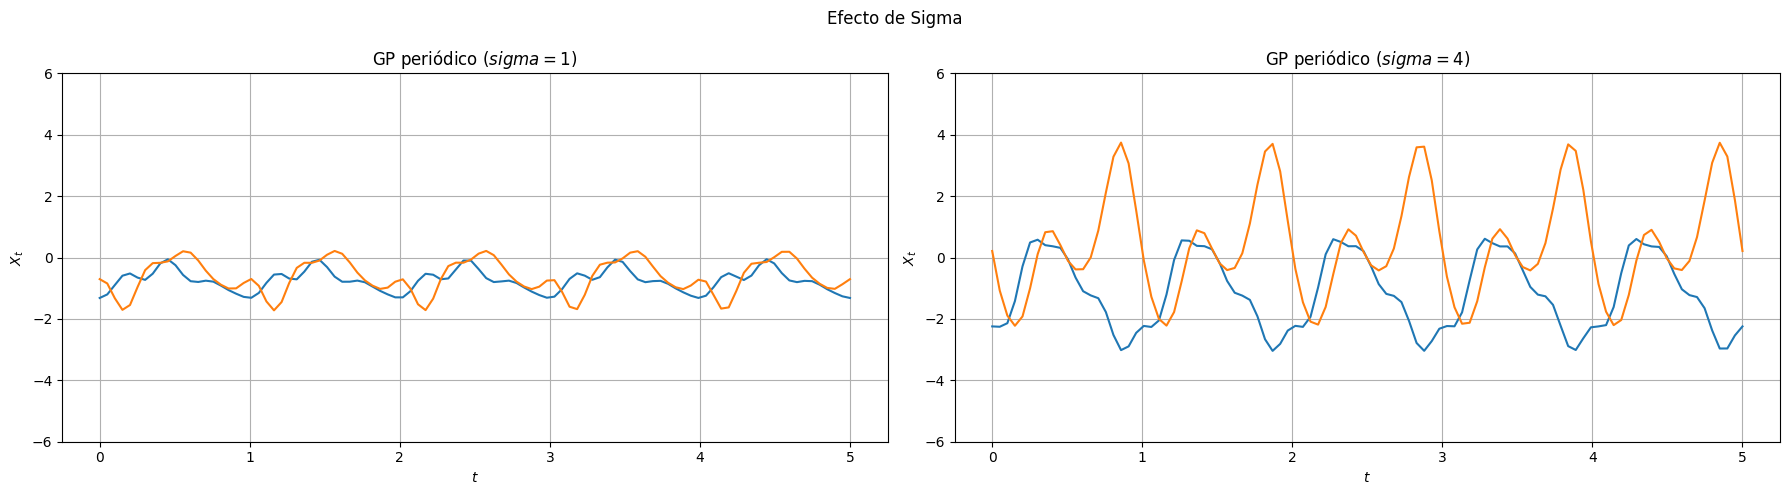

In [ ]:
t = np.linspace(0, 5, 100)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plt.suptitle('Efecto de Sigma')

axes[0].plot(t, simular_GP_periodic (t, 1, 1 ,1, 2).T)
axes[0].grid()
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_ylim(-6,6)
axes[0].set_title('GP periódico ($sigma = 1$)')


axes[1].plot(t, simular_GP_periodic (t, 4 ,1 , 1, 2).T)
axes[1].grid()
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_ylim(-6,6)
axes[1].set_title('GP periódico ($sigma = 4$)')

plt.tight_layout()
plt.show()

**4.Simular un GP con kernel DPK (polinómico hasta grado m)**

Definiremos simular_GP_DPKpoly, una función que permita hacerlo, será un kernel con funciones base  $1, t,..., t^m$. Con función de medias constantemente igual a cero.

In [ ]:
def simular_GP_DPKpoly(t, m=1, num_samples=1):

    # Obtenemos el n
    n = t.shape[0]

    # Vector de medias
    vector_medias = np.zeros_like(t)

    # Potencias de 0 a m
    potencias = np.arange(m + 1)
    F = t[:, np.newaxis] ** potencias[np.newaxis, :] # F.shape será (n, m+1)

    # Matriz de covarianzas como F @ F.T
    matriz_covs = F @ F.T

    # Añadimos "jitter" para que sea semidefinida positiva
    matriz_covs = matriz_covs + 1e-9 * np.eye(n)

    # Muestras
    samples = np.random.multivariate_normal(mean=vector_medias, cov=matriz_covs, size=num_samples)

    return samples

Veamos algunas gráficas.

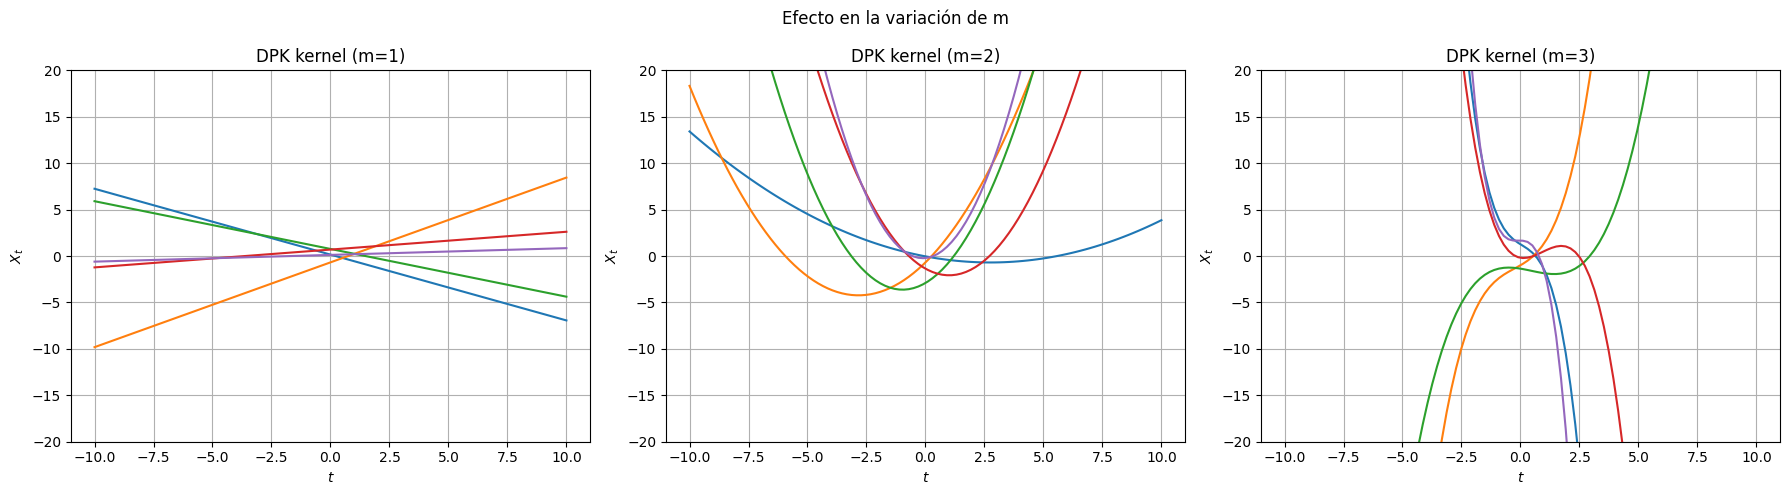

In [ ]:
t = np.linspace(-10, 10, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle('Efecto en la variación de m')

axes[0].plot(t, simular_GP_DPKpoly (t, 1, 5).T)
axes[0].grid()
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')
axes[0].set_ylim(-20,20)
axes[0].set_title('DPK kernel (m=1)')


axes[1].plot(t, simular_GP_DPKpoly (t, 2, 5).T)
axes[1].grid()
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$X_t$')
axes[1].set_ylim(-20,20)
axes[1].set_title('DPK kernel (m=2)')

axes[2].plot(t, simular_GP_DPKpoly (t, 3, 5).T)
axes[2].grid()
axes[2].set_xlabel('$t$')
axes[2].set_ylabel('$X_t$')
axes[2].set_ylim(-20,20)
axes[2].set_title('DPK kernel (m=3)')


plt.tight_layout()
plt.show()

**5. ¿Cómo podemos pasar el kernel como parámetro?**

Veamos una solución basada en el paradigma de programación orientada a objetos (POO). Definiendo una clase para describir el kernel RBF.

In [ ]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

Creamos un objeto de este tipo:

In [ ]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100

<class '__main__.RBF'>
(100, 100)


In [ ]:
class Zero_Mean_Function: ## Clase para función de medias constantemente igual a cero.
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

In [ ]:
my_mf = Zero_Mean_Function() # Objeto
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

<class '__main__.Zero_Mean_Function'>
(100,)
True


Ahora definimos la función:

In [ ]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

In [ ]:
class Identity_Mean_Function: # Clase para la función de medias identidad
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Ahora recreemos la última gráfica para asegurarnos que todo está bien.

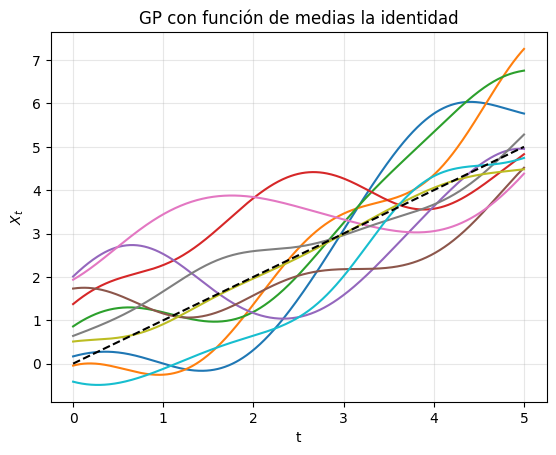

In [ ]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP con función de medias la identidad")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()